Aula 1

In [1]:
import pandas as pd

In [2]:
df_excel = pd.read_excel('Chess.xlsx', sheet_name='Chess')

In [3]:
df_csv = pd.read_csv('Tomato.csv', sep=',')

In [4]:
df_excel.head(2)

,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,opening_eco,opening_name,opening_ply
0,False,1.504210e+17,1.504210e+17,13,outoftime,white,15+2,bourgris,1500,a-00,1191,D10,Slav Defense: Exchange Variation,5
1,True,1.504130e+17,1.504130e+17,16,resign,black,5+10,a-00,1322,skinnerua,1261,B00,Nimzowitsch Defense: Kennedy Variation,4


In [5]:
df_csv.tail(2)

,Date,Unit,Minimum,Maximum,Average,Market
2739,2021-05-12,Kg,30,35,32.5,Tomato
2740,2021-05-13,Kg,35,40,37.5,Tomato


In [6]:
df_csv.shape

(2741, 6)

In [7]:
df_excel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rated           20058 non-null  bool   
 1   created_at      20058 non-null  float64
 2   last_move_at    20058 non-null  float64
 3   turns           20058 non-null  int64  
 4   victory_status  20058 non-null  object 
 5   winner          20058 non-null  object 
 6   increment_code  20058 non-null  object 
 7   white_id        20058 non-null  object 
 8   white_rating    20058 non-null  int64  
 9   black_id        20058 non-null  object 
 10  black_rating    20058 non-null  int64  
 11  opening_eco     20058 non-null  object 
 12  opening_name    20058 non-null  object 
 13  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(7)
memory usage: 2.0+ MB


In [8]:
df_csv.describe().T

,count,mean,std,min,25%,50%,75%,max
Minimum,2741.0,35.089748,16.648425,8.0,22.0,30.0,45.0,115.0
Maximum,2741.0,41.281284,17.364135,12.0,30.0,38.0,50.0,120.0
Average,2741.0,38.185516,16.970949,10.0,25.0,35.0,47.5,117.5


In [9]:
df_excel.head(2)

,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,opening_eco,opening_name,opening_ply
0,False,1.504210e+17,1.504210e+17,13,outoftime,white,15+2,bourgris,1500,a-00,1191,D10,Slav Defense: Exchange Variation,5
1,True,1.504130e+17,1.504130e+17,16,resign,black,5+10,a-00,1322,skinnerua,1261,B00,Nimzowitsch Defense: Kennedy Variation,4


In [10]:
set(df_excel['victory_status'])

{'draw', 'mate', 'outoftime', 'resign'}

In [11]:
df_csv.head()

,Date,Unit,Minimum,Maximum,Average,Market
0,2013-06-16,Kg,26,32,29.0,Tomato
1,2013-06-17,Kg,20,25,22.5,Tomato
2,2013-06-18,Kg,22,26,24.0,Tomato
3,2013-06-19,Kg,24,28,26.0,Tomato
4,2013-06-20,Kg,22,26,24.0,Tomato


In [12]:
set(df_csv['Market'])

{'Tomato'}

In [13]:
def categorizar_tomate_media(media):
  if media >= 40 and media <= 70:
    return 'tomate medio'
  elif media < 40:
    return 'tomate pequeno'
  else:
    return 'tomatão'



In [14]:
df_csv['categoria_tomate'] = df_csv['Average'].apply(categorizar_tomate_media)

In [15]:
df_csv.head(2)

,Date,Unit,Minimum,Maximum,Average,Market,categoria_tomate
0,2013-06-16,Kg,26,32,29.0,Tomato,tomate pequeno
1,2013-06-17,Kg,20,25,22.5,Tomato,tomate pequeno


In [16]:
df_csv.groupby(['categoria_tomate']).describe().reset_index()

categoria_tomate Minimum                                               \
                     count       mean       std   min   25%   50%   75%   
0     tomate medio   954.0  47.818658  8.203065  30.0  40.0  45.0  55.0   
1   tomate pequeno  1638.0  23.978022  7.175572   8.0  18.0  25.0  30.0   
2          tomatão   149.0  75.744966  7.324666  65.0  70.0  75.0  80.0   

         Maximum  ...              Average                                   \
     max   count  ...   75%    max   count       mean       std   min   25%   
0   65.0   954.0  ...  60.0   75.0   954.0  51.414046  8.272792  40.0  45.0   
1   38.0  1638.0  ...  35.0   44.0  1638.0  26.753358  7.191735  10.0  21.5   
2  115.0   149.0  ...  85.0  120.0   149.0  79.164430  7.367396  70.5  75.0   

                      
    50%   75%    max  
0  50.0  57.5   70.0  
1  27.5  32.5   39.5  
2  77.5  82.5  117.5  

[3 rows x 25 columns]

In [17]:
filtro = df_csv['Average'] < 40
df_csv.loc[filtro]

,Date,Unit,Minimum,Maximum,Average,Market,categoria_tomate
0,2013-06-16,Kg,26,32,29.0,Tomato,tomate pequeno
1,2013-06-17,Kg,20,25,22.5,Tomato,tomate pequeno
2,2013-06-18,Kg,22,26,24.0,Tomato,tomate pequeno
3,2013-06-19,Kg,24,28,26.0,Tomato,tomate pequeno
4,2013-06-20,Kg,22,26,24.0,Tomato,tomate pequeno
...,...,...,...,...,...,...,...
2736,2021-05-09,Kg,10,15,12.5,Tomato,tomate pequeno
2737,2021-05-10,Kg,10,15,12.5,Tomato,tomate pequeno
2738,2021-05-11,Kg,10,15,12.5,Tomato,tomate pequeno
2739,2021-05-12,Kg,30,35,32.5,Tomato,tomate pequeno


In [18]:
import numpy as np

In [19]:
arr_list = np.array([1, 2, 3, 4, 5, 6, 7, 8])

In [20]:
print(arr_list)

[1 2 3 4 5 6 7 8]


In [21]:
arr_zeros = np.zeros((4, 6))

In [22]:
print(arr_zeros)

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


In [23]:
arr_ones = np.ones((3, 4))

In [24]:
print(arr_ones)

[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


In [25]:
arr_random = np.random.rand(3,4) * 5

In [26]:
print(arr_random)

[[3.22557284 0.31768504 1.26921294 3.04225346]
 [3.81543401 2.37506251 2.50767759 3.65128564]
 [0.26925318 1.7066729  2.35137347 4.23621018]]


In [27]:
print(arr_random.shape)

(3, 4)


In [28]:
arr_random_reshape = arr_random.reshape((4,3))

In [29]:
print(arr_random_reshape)

[[3.22557284 0.31768504 1.26921294]
 [3.04225346 3.81543401 2.37506251]
 [2.50767759 3.65128564 0.26925318]
 [1.7066729  2.35137347 4.23621018]]


In [30]:
arr1 = np.array([[1, 2], [3, 4]])
arr2 = np.array([[5, 6], [7, 8]])
arr3 = np.array([[9, 10], [11, 12]])

In [31]:
arr4 = np.concatenate((arr1, arr2, arr3), axis=1)

In [32]:
arr4

array([[ 1,  2,  5,  6,  9, 10],
       [ 3,  4,  7,  8, 11, 12]])

In [33]:
arr4_split = np.split(arr4, 2)

In [34]:
print(arr4_split)

[array([[ 1,  2,  5,  6,  9, 10]]), array([[ 3,  4,  7,  8, 11, 12]])]


In [35]:
arr4_transpose = np.transpose(arr4)

In [36]:
print(arr4_transpose)

[[ 1  3]
 [ 2  4]
 [ 5  7]
 [ 6  8]
 [ 9 11]
 [10 12]]


In [37]:
arr4_revertido = arr4_transpose.T

In [38]:
arr4_revertido

array([[ 1,  2,  5,  6,  9, 10],
       [ 3,  4,  7,  8, 11, 12]])

In [39]:
arr_a = np.array([1, 7, 27])
arr_b = np.array([1, 5, 1])

In [40]:
arr_a_b = np.add(arr_a, arr_b)

In [41]:
arr_a_b

array([ 2, 12, 28])

In [42]:
arr_sub_a_b = np.subtract(arr_a, arr_b)

In [43]:
arr_sub_a_b

array([ 0,  2, 26])

In [44]:
import matplotlib.pyplot as plt

In [45]:
df_tomato = pd.read_csv('Tomato.csv', sep=',')

In [46]:
df_tomato.head()

,Date,Unit,Minimum,Maximum,Average,Market
0,2013-06-16,Kg,26,32,29.0,Tomato
1,2013-06-17,Kg,20,25,22.5,Tomato
2,2013-06-18,Kg,22,26,24.0,Tomato
3,2013-06-19,Kg,24,28,26.0,Tomato
4,2013-06-20,Kg,22,26,24.0,Tomato


In [47]:
df_tomato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2741 entries, 0 to 2740
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2741 non-null   object 
 1   Unit     2741 non-null   object 
 2   Minimum  2741 non-null   int64  
 3   Maximum  2741 non-null   int64  
 4   Average  2741 non-null   float64
 5   Market   2741 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 128.6+ KB


In [48]:
df_tomato['Date'] = pd.to_datetime(df_tomato['Date'])

In [49]:
df_tomato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2741 entries, 0 to 2740
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2741 non-null   datetime64[ns]
 1   Unit     2741 non-null   object        
 2   Minimum  2741 non-null   int64         
 3   Maximum  2741 non-null   int64         
 4   Average  2741 non-null   float64       
 5   Market   2741 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 128.6+ KB


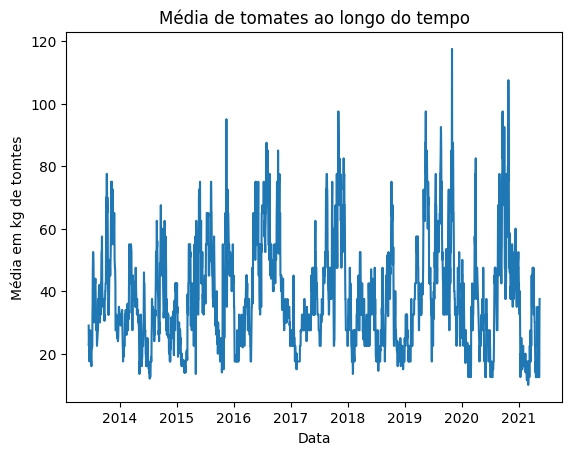

In [50]:
plt.plot(df_tomato['Date'], df_tomato['Average'])
plt.xlabel('Data')
plt.ylabel('Média em kg de tomtes')
plt.title('Média de tomates ao longo do tempo')
plt.show()

In [51]:
df_chess = pd.read_excel('Chess.xlsx', sheet_name='Chess')

In [52]:
df_chess.head()

,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,opening_eco,opening_name,opening_ply
0,False,1.504210e+17,1.504210e+17,13,outoftime,white,15+2,bourgris,1500,a-00,1191,D10,Slav Defense: Exchange Variation,5
1,True,1.504130e+17,1.504130e+17,16,resign,black,5+10,a-00,1322,skinnerua,1261,B00,Nimzowitsch Defense: Kennedy Variation,4
2,True,1.504130e+17,1.504130e+17,61,mate,white,5+10,ischia,1496,a-00,1500,C20,King's Pawn Game: Leonardis Variation,3
3,True,1.504110e+17,1.504110e+17,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,D02,Queen's Pawn Game: Zukertort Variation,3
4,True,1.504030e+17,1.504030e+17,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,C41,Philidor Defense,5


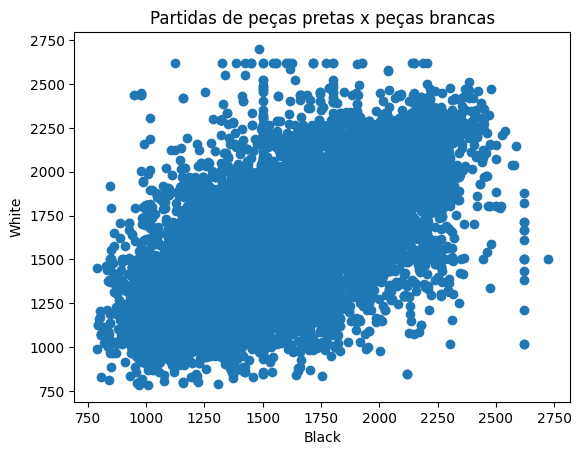

In [53]:
plt.scatter(df_chess['black_rating'], df_chess['white_rating'])
plt.xlabel('Black')
plt.ylabel('White')
plt.title('Partidas de peças pretas x peças brancas')
plt.show()

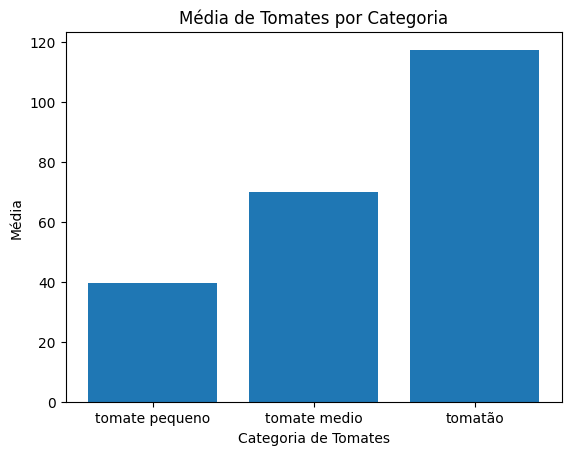

In [54]:
plt.bar(df_csv['categoria_tomate'], df_csv['Average'])
plt.xlabel('Categoria de Tomates')
plt.ylabel('Média')
plt.title('Média de Tomates por Categoria')
plt.show()

In [55]:
df_chess.head(2)

,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,opening_eco,opening_name,opening_ply
0,False,1.504210e+17,1.504210e+17,13,outoftime,white,15+2,bourgris,1500,a-00,1191,D10,Slav Defense: Exchange Variation,5
1,True,1.504130e+17,1.504130e+17,16,resign,black,5+10,a-00,1322,skinnerua,1261,B00,Nimzowitsch Defense: Kennedy Variation,4


In [56]:
df_chess.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rated           20058 non-null  bool   
 1   created_at      20058 non-null  float64
 2   last_move_at    20058 non-null  float64
 3   turns           20058 non-null  int64  
 4   victory_status  20058 non-null  object 
 5   winner          20058 non-null  object 
 6   increment_code  20058 non-null  object 
 7   white_id        20058 non-null  object 
 8   white_rating    20058 non-null  int64  
 9   black_id        20058 non-null  object 
 10  black_rating    20058 non-null  int64  
 11  opening_eco     20058 non-null  object 
 12  opening_name    20058 non-null  object 
 13  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(7)
memory usage: 2.0+ MB


In [57]:
df_chess['victory_status'] = df_chess['victory_status'].astype('string')

In [58]:
df_chess.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rated           20058 non-null  bool   
 1   created_at      20058 non-null  float64
 2   last_move_at    20058 non-null  float64
 3   turns           20058 non-null  int64  
 4   victory_status  20058 non-null  string 
 5   winner          20058 non-null  object 
 6   increment_code  20058 non-null  object 
 7   white_id        20058 non-null  object 
 8   white_rating    20058 non-null  int64  
 9   black_id        20058 non-null  object 
 10  black_rating    20058 non-null  int64  
 11  opening_eco     20058 non-null  object 
 12  opening_name    20058 non-null  object 
 13  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(6), string(1)
memory usage: 2.0+ MB


In [59]:
#df_chess.groupby(['victory_status']).mean().plot(kind='pie', y='turns', autopct='%1.0f%%')
#plt.title('Média de partidas dentro de status de vitória')
#plt.show()

In [60]:
#df_excel.groupby(['victory_status']).mean()

In [61]:
set(df_chess['victory_status'])

{'draw', 'mate', 'outoftime', 'resign'}

In [62]:
! pip install scikit-learn

In [63]:
df_diabetes = pd.read_csv('diabetes.csv', sep=',')

In [64]:
df_diabetes.head(3)

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [65]:
from sklearn.model_selection import train_test_split

In [66]:
x = df_diabetes.drop(['Class variable'], axis=1)

In [67]:
x

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years)
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [68]:
y = df_diabetes['Class variable']

In [69]:
y

,Class variable
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [70]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

In [71]:
len(x_train)

537

In [72]:
df_diabetes.shape

(768, 9)

In [73]:
len(x_test)

231

In [74]:
from sklearn.neighbors import KNeighborsClassifier

In [75]:
knn = KNeighborsClassifier(n_neighbors=3)

In [76]:
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [77]:
accuracy = knn.score(x_test, y_test)

In [78]:
accuracy

0.696969696969697

In [79]:
df = pd.read_excel('dataset_rolling_stones.xlsx')

In [80]:
df.head(3)

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              1610 non-null   object        
 1   album             1610 non-null   object        
 2   release_date      1610 non-null   datetime64[ns]
 3   track_number      1610 non-null   int64         
 4   acousticness      1610 non-null   float64       
 5   danceability      1610 non-null   float64       
 6   energy            1610 non-null   float64       
 7   instrumentalness  1610 non-null   float64       
 8   liveness          1610 non-null   float64       
 9   loudness          1610 non-null   float64       
 10  speechiness       1610 non-null   float64       
 11  tempo             1610 non-null   float64       
 12  valence           1610 non-null   float64       
 13  popularity        1610 non-null   int64         
 14  duration_ms       1610 n

In [82]:
df.shape

(1610, 15)

In [83]:
print('Data Inicial: ', df['release_date'].min())

Data Inicial:  1964-04-16 00:00:00


In [84]:
print('Data Final: ', df['release_date'].max())

Data Final:  2022-06-10 00:00:00


In [85]:
df.isnull().sum()

,0
name,0
album,0
release_date,0
track_number,0
acousticness,0
danceability,0
energy,0
instrumentalness,0
liveness,0
loudness,0


In [86]:
df.duplicated().sum()

np.int64(6)

In [87]:
df[df.duplicated()]

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
928,Some Girls - Remastered,Some Girls (Deluxe Version),1978-06-09,4,0.5270,0.474,0.938,0.520000,0.299,-2643.0,0.0898,71995.00,0.505,21,276933
929,Lies - Remastered,Some Girls (Deluxe Version),1978-06-09,5,0.4370,0.382,0.997,0.950000,0.617,-1568.0,0.1880,162428.00,0.563,16,191266
935,Claudine,Some Girls (Deluxe Version),1978-06-09,1,0.0144,0.439,0.977,0.022100,0.383,-4386.0,0.1280,105124.00,0.364,17,222253
939,No Spare Parts,Some Girls (Deluxe Version),1978-06-09,5,0.2400,0.594,0.762,0.000015,0.712,-5145.0,0.0292,72648.00,0.540,19,270466
940,Don't Be A Stranger,Some Girls (Deluxe Version),1978-06-09,6,0.0610,0.720,0.867,0.029700,0.385,-5871.0,0.0390,127329.00,0.847,15,246266
946,Petrol Blues,Some Girls (Deluxe Version),1978-06-09,12,0.7690,0.835,0.621,0.114000,0.116,-8007.0,0.0406,115.87,0.336,13,95626


In [88]:
df.describe()

,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1992-04-23 12:57:14.534161536,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6406.640075,0.069512,114078.725261,0.582165,20.788199,257736.488199
min,1964-04-16 00:00:00,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24408.000000,0.023200,65.990000,0.000000,0.000000,21000.000000
25%,1970-09-04 00:00:00,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8829.500000,0.036500,98996.500000,0.404250,13.000000,190613.000000
50%,1986-03-24 00:00:00,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6179.000000,0.051200,120319.000000,0.583000,20.000000,243093.000000
75%,2017-12-01 00:00:00,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4254.750000,0.086600,140853.750000,0.778000,27.000000,295319.750000
max,2022-06-10 00:00:00,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-2.310000,0.624000,216304.000000,0.974000,80.000000,981866.000000
std,NaN,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,3474.285941,0.051631,46196.602233,0.231253,12.426859,108333.474920


In [89]:
df['duracao_em_min'] = df['duration_ms'] / 60000

In [90]:
df.head(3)

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160,4.386000


In [91]:
df.describe()

,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min
count,1610,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1992-04-23 12:57:14.534161536,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6406.640075,0.069512,114078.725261,0.582165,20.788199,257736.488199,4.295608
min,1964-04-16 00:00:00,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24408.000000,0.023200,65.990000,0.000000,0.000000,21000.000000,0.350000
25%,1970-09-04 00:00:00,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8829.500000,0.036500,98996.500000,0.404250,13.000000,190613.000000,3.176883
50%,1986-03-24 00:00:00,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6179.000000,0.051200,120319.000000,0.583000,20.000000,243093.000000,4.051550
75%,2017-12-01 00:00:00,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4254.750000,0.086600,140853.750000,0.778000,27.000000,295319.750000,4.921996
max,2022-06-10 00:00:00,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-2.310000,0.624000,216304.000000,0.974000,80.000000,981866.000000,16.364433
std,NaN,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,3474.285941,0.051631,46196.602233,0.231253,12.426859,108333.474920,1.805558


In [92]:
df.groupby('album')['duracao_em_min'].mean()

,duracao_em_min
album,
12 X 5,2.682068
12 x 5,2.682772
A Bigger Bang (2009 Re-Mastered),4.016356
A Bigger Bang (Live),5.176630
Aftermath,3.899185
...,...
Undercover,4.492750
Undercover (2009 Re-Mastered),4.497595
Voodoo Lounge (Remastered 2009),4.118779


In [93]:
import matplotlib.pyplot as plt

In [94]:
df_maior_duracao_musica = df.groupby('album')['duracao_em_min'].mean().sort_values(ascending=False)

In [95]:
df_maior_duracao_musica

,duracao_em_min
album,
Havana Moon (Live),6.632819
Bridges To Bremen (Live),6.332265
Jamming With Edward,6.042794
Live At The Checkerboard Lounge,6.009647
Totally Stripped - Paris (Live),5.947430
...,...
Out Of Our Heads (UK),2.464643
Out Of Our Heads (UK Sequence),2.449274
December's Children (and everybody's),2.408976


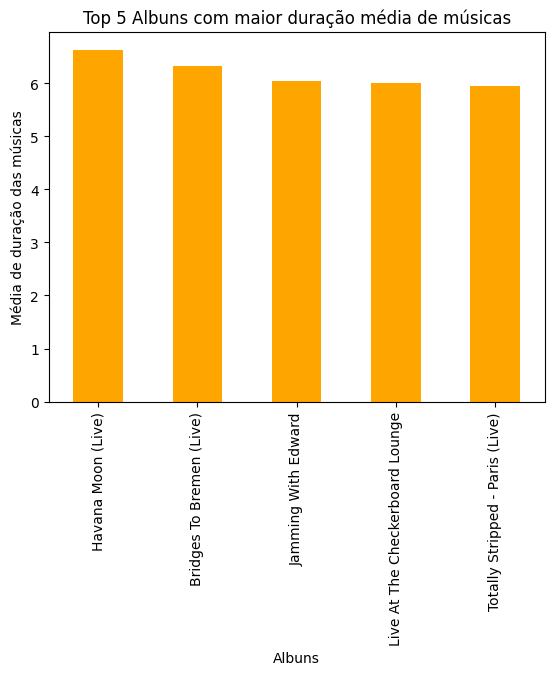

In [96]:
df_maior_duracao_musica.head(5).plot(kind='bar', color = 'orange')
plt.xlabel('Albuns')
plt.ylabel('Média de duração das músicas')
plt.title('Top 5 Albuns com maior duração média de músicas')
plt.show()

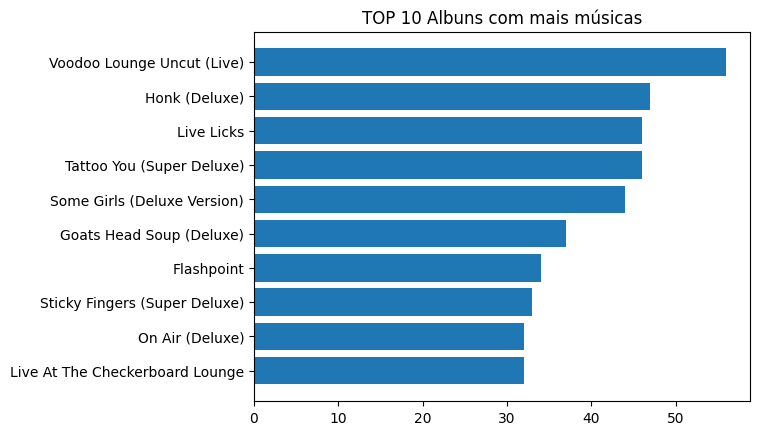

In [97]:
top_albuns = df['album'].value_counts().head(10).sort_values(ascending=True)
plt.barh(top_albuns.index, top_albuns.values)
plt.title('TOP 10 Albuns com mais músicas')
plt.show()

In [98]:
top_albuns = df['album'].value_counts().head(10).sort_values(ascending=True)

In [99]:
top_albuns

,count
album,
Live At The Checkerboard Lounge,32
On Air (Deluxe),32
Sticky Fingers (Super Deluxe),33
Flashpoint,34
Goats Head Soup (Deluxe),37
Some Girls (Deluxe Version),44
Tattoo You (Super Deluxe),46
Live Licks,46
Honk (Deluxe),47


In [100]:
df_ultima_decada = df[df['release_date'].between(pd.to_datetime('2011'), pd.to_datetime('2020'))]

In [101]:
df_por_album = df_ultima_decada.groupby('album')['popularity'].sum().sort_values(ascending=False).head(10)

In [102]:
df_por_album

,popularity
album,
Honk (Deluxe),1232
Voodoo Lounge Uncut (Live),654
On Air (Deluxe),573
Live At The Checkerboard Lounge,482
Havana Moon (Live),445
Bridges To Buenos Aires (Live),433
Blue & Lonesome,419
Bridges To Bremen (Live),396
Some Girls: Live In Texas '78,344


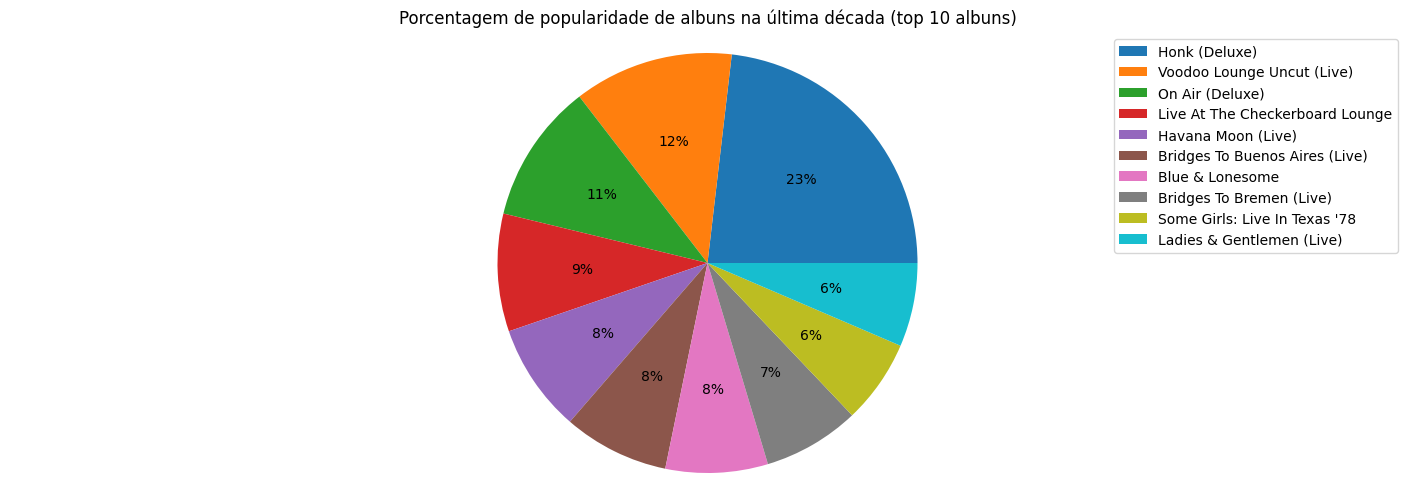

In [103]:
total_popularidade = df_por_album.sum()

df_porcentagem = df_por_album / total_popularidade * 100

labels = df_porcentagem.index.tolist()
sizes = df_porcentagem.values.tolist()

figura, grafico = plt.subplots(figsize=(18,6))
grafico.pie(sizes, autopct='%1.0f%%')
grafico.axis('equal')
plt.title('Porcentagem de popularidade de albuns na última década (top 10 albuns)')
plt.legend(labels, loc='best')
plt.show()

In [104]:
import seaborn as sns

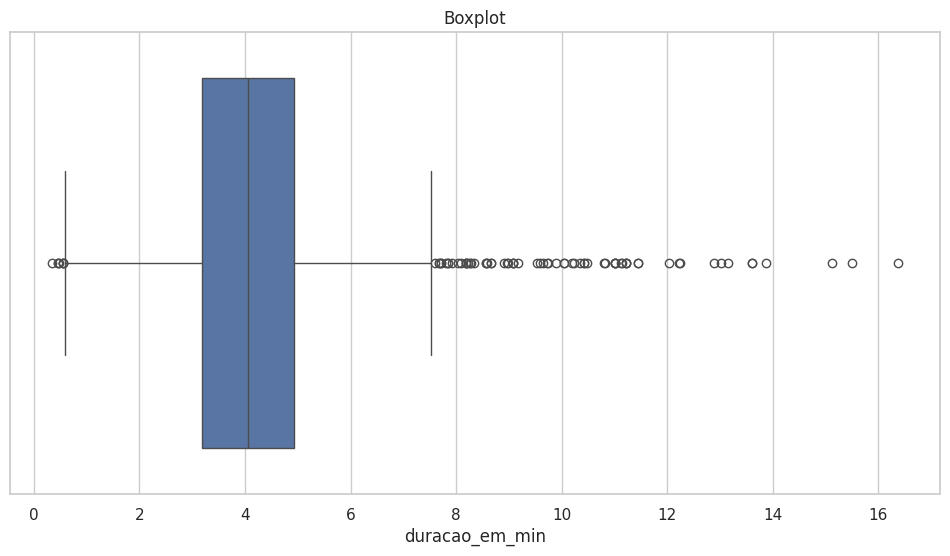

In [105]:
sns.set(style='whitegrid')
fig, axes = plt.subplots(figsize=(12,6))
sns.boxplot(x='duracao_em_min', data=df)
axes.set_title('Boxplot')
plt.show()

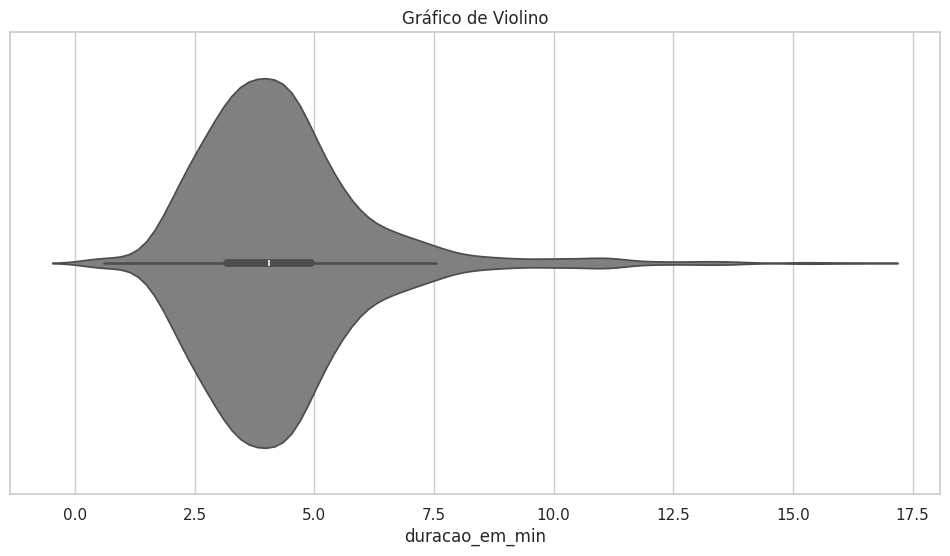

In [106]:
fig, axes = plt.subplots(figsize=(12,6))
sns.violinplot(x='duracao_em_min', data=df, color='gray')
axes.set_title('Gráfico de Violino')
plt.show()

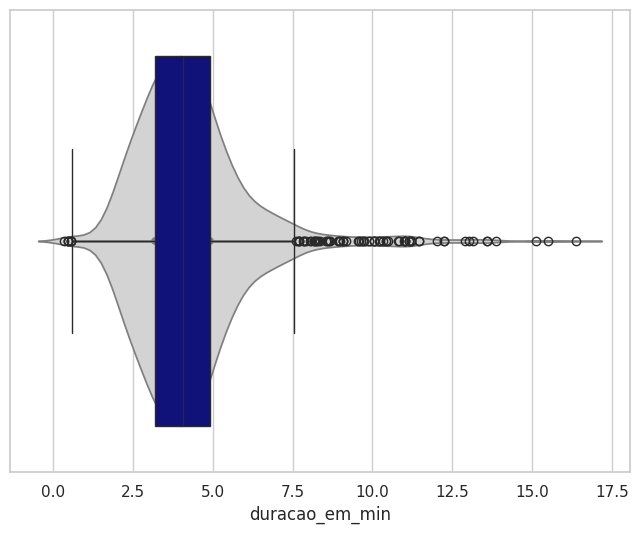

In [107]:
fig, ax = plt.subplots(figsize=(8,6))
sns.violinplot(x='duracao_em_min', data=df, ax=ax, color='lightgray')
sns.boxplot(x='duracao_em_min', data=df, ax=ax, whis=1.5, color='darkblue')
axes.set_title('Visualização Violini e Boxplot')
plt.show()

In [108]:
df.head(4)

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160,4.386000
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880,5.098000


In [109]:
def classifica_musica_ao_vivo(df):
  if df['liveness'] >= 0.8:
    return True
  else:
    return False

In [110]:
df['ao_vivo'] = df.apply(classifica_musica_ao_vivo, axis=1)

In [111]:
df.head(3)

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min,ao_vivo
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667,True
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550,True
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160,4.386000,True


In [112]:
df.groupby('ao_vivo')['ao_vivo'].count()

,ao_vivo
ao_vivo,
False,1112
True,498


In [113]:
df_gravado_em_estudio = df[df['ao_vivo'] == False]
df_show_ao_vivo = df[df['ao_vivo'] == True]

In [114]:
df_gravado_em_estudio.head(3)

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min,ao_vivo
5,Monkey Man - Live,Licked Live In NYC,2022-06-10,6,0.2750,0.340,0.956,0.1250,0.741,-5539.0,0.0915,101628.0,0.125,31,244293,4.071550,False
23,Honky Tonk Women - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,1,0.1620,0.430,0.901,0.0110,0.694,-6215.0,0.0450,112077.0,0.890,32,216546,3.609100,False
25,Hand Of Fate - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,3,0.0654,0.477,0.899,0.0376,0.727,-6189.0,0.0425,129991.0,0.805,29,267866,4.464433,False


In [115]:
print('média das músicas ao vivo: ', df_show_ao_vivo['duracao_em_min'].mean())

média das músicas ao vivo:  5.088648962516734


In [116]:
print('média das músicas em estudio: ', df_gravado_em_estudio['duracao_em_min'].mean())

média das músicas em estudio:  3.940451363908873


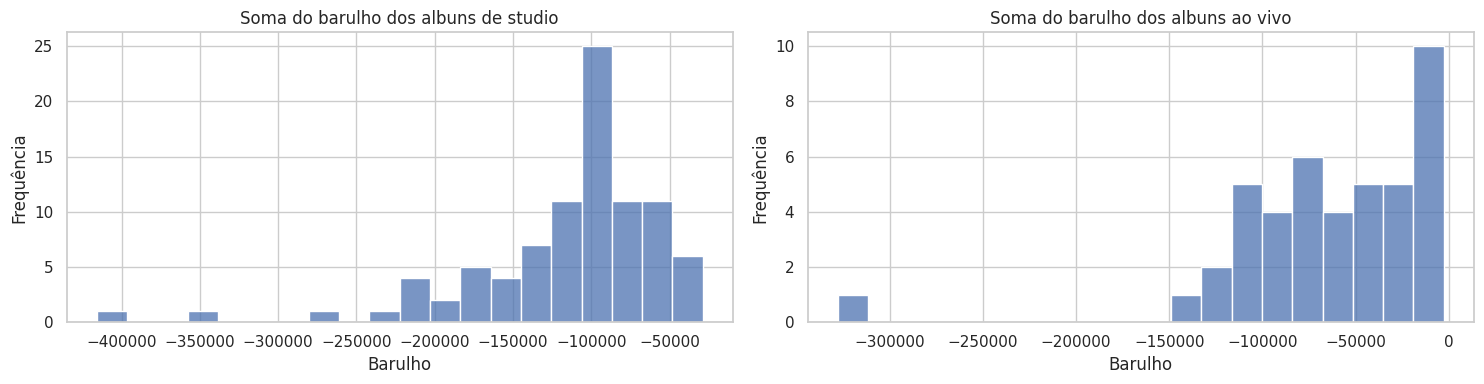

In [117]:
df_studio = df.groupby('album')['loudness'].sum()
df_ao_vivo = df_show_ao_vivo.groupby('album')['loudness'].sum()

fig, axes = plt.subplots(1, 2, figsize=(15,4))

sns.histplot(data=df_studio, bins=20, ax=axes[0])
axes[0].set_title('Soma do barulho dos albuns de studio')
axes[0].set_xlabel('Barulho')
axes[0].set_ylabel('Frequência')

sns.histplot(data=df_ao_vivo, bins=20, ax=axes[1])
axes[1].set_title('Soma do barulho dos albuns ao vivo')
axes[1].set_xlabel('Barulho')
axes[1].set_ylabel('Frequência')

fig.tight_layout()
plt.show()

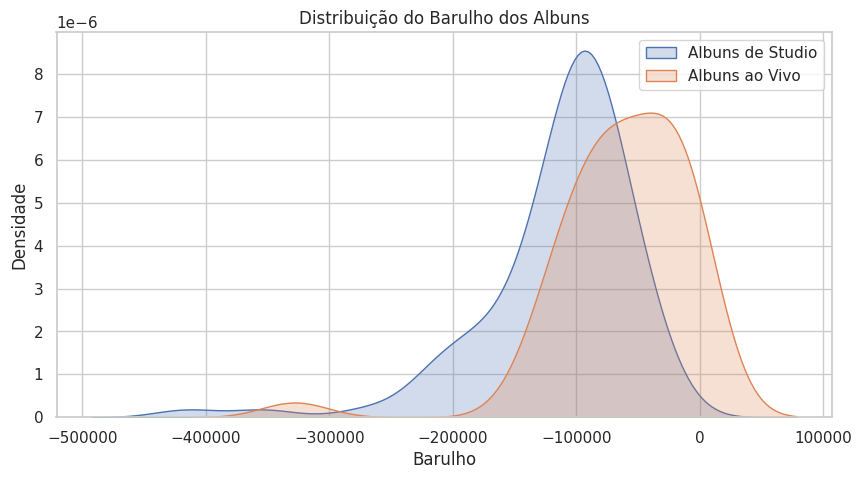

In [118]:
plt.figure(figsize=(10,5))

sns.kdeplot(data=df_studio, label='Albuns de Studio', fill=True)
sns.kdeplot(data=df_ao_vivo, label='Albuns ao Vivo', fill=True)

plt.title('Distribuição do Barulho dos Albuns')
plt.xlabel('Barulho')
plt.ylabel('Densidade')
plt.legend()
plt.show()


In [119]:
from scipy.stats import shapiro

In [120]:
stat, p = shapiro(df_studio)
print('Soma do Barulho dos albuns de studio: ')
print('Estatístca de teste: {:.4f}, valor p: {}'.format(stat, p))

if p > 0.05:
  print('Não há evidência suficiente para rejeitar a hipótese de normalidade')
else:
  print('A hipótese de normalidade é rejeitada')

Soma do Barulho dos albuns de studio: 
Estatístca de teste: 0.8221, valor p: 4.929704786702674e-09
A hipótese de normalidade é rejeitada


In [121]:
stat, p = shapiro(df_ao_vivo)
print('Soma do Barulho dos ao vivo: ')
print('Estatístca de teste: {:.4f}, valor p: {}'.format(stat, p))

if p > 0.05:
  print('Não há evidência suficiente para rejeitar a hipótese de normalidade')
else:
  print('A hipótese de normalidade é rejeitada')

Soma do Barulho dos ao vivo: 
Estatístca de teste: 0.7913, valor p: 2.3506009149709294e-06
A hipótese de normalidade é rejeitada


In [122]:
from scipy.stats import mannwhitneyu

In [123]:
stat, p = mannwhitneyu(df_studio.sample(len(df_studio)), df_ao_vivo.sample(len(df_ao_vivo)), alternative='less')

print('Estatística de teste U: ', stat)
print('Valor p', p)

alpha = 0.05

if p < alpha:
  print('Diferença e estatisticamente significante')
else:
  print('Não há diferença estatisticamente significante')

Estatística de teste U:  855.0
Valor p 1.0354474363299594e-07
Diferença e estatisticamente significante


In [124]:
# Correlação (análise de sentimento de música por meio da valencia)

media_por_album = df.groupby('album')['valence'].mean().reset_index()

media_por_album = media_por_album.rename(columns={'valence': 'media_valence'})

media_por_album['sentimento'] = ['Positivo' if v > 0.6 else 'Negativo' for v in media_por_album['media_valence']]

media_por_album.groupby('sentimento')['sentimento'].count()

,sentimento
sentimento,
Negativo,38
Positivo,52


In [125]:
media_por_album.head(3)

,album,media_valence,sentimento
0,12 X 5,0.704000,Positivo
1,12 x 5,0.689917,Positivo
2,A Bigger Bang (2009 Re-Mastered),0.602750,Positivo


In [126]:
df_resultado_final = pd.merge(df, media_por_album, on = 'album')

In [127]:
df_resultado_final.head(2)



,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min,ao_vivo,media_valence,sentimento
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667,True,0.27117,Negativo
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550,True,0.27117,Negativo


In [128]:
df_resultado_final = df_resultado_final.drop('album', axis=1)

In [129]:
df_resultado_final = df_resultado_final.drop('sentimento', axis=1)

In [130]:
# matriz_correlacao = df_resultado_final.corr()

# correlacao_sentimento = matriz_correlacao['media_valence']

# display(correlacao_sentimento)

In [131]:
# sns.heatmap(correlacao_sentimento.to_frame(), annot=True, cmap = 'coolwarm')
# plt.show()

In [132]:
df_resultado_final_novo = pd.merge(df, media_por_album, on = 'album')

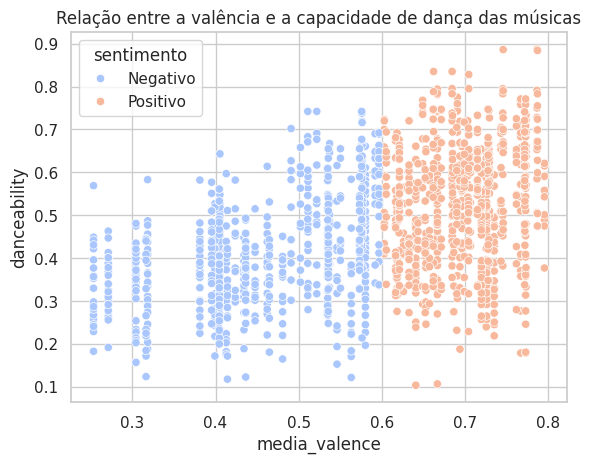

In [133]:
sns.scatterplot(x='media_valence', y='danceability', hue='sentimento', data=df_resultado_final_novo, palette = 'coolwarm')
plt.xlabel('media_valence')
plt.ylabel('danceability')
plt.title('Relação entre a valência e a capacidade de dança das músicas')
plt.show()

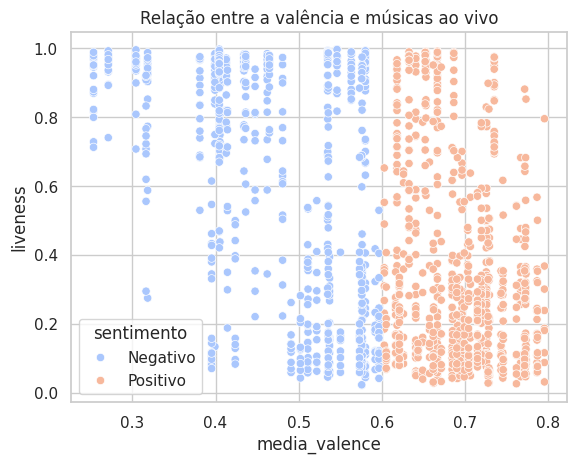

In [134]:
sns.scatterplot(x='media_valence', y='liveness', hue='sentimento', data=df_resultado_final_novo, palette='coolwarm')
plt.xlabel('media_valence')
plt.ylabel('liveness')
plt.title('Relação entre a valência e músicas ao vivo')
plt.show()

In [135]:
# Normalização e padronização de dados - feature scaling
# Tipo de algoritmos que lidam com distâncias: k-means, knn, pca, svm e regressão logística

In [136]:
df_churn = pd.read_csv('Churn_Modelling.csv', sep=';')

In [137]:
df_churn.head(2)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


In [138]:
df_churn.shape

(9865, 14)

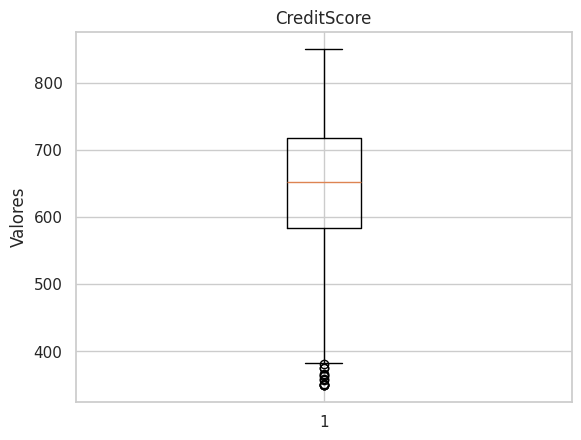

In [139]:
# gráfico boxplot

plt.boxplot(df_churn['CreditScore'])
plt.title('CreditScore')
plt.ylabel('Valores')
plt.show()

In [140]:
print(df_churn['CreditScore'].min())
print(df_churn['CreditScore'].max())

350
850


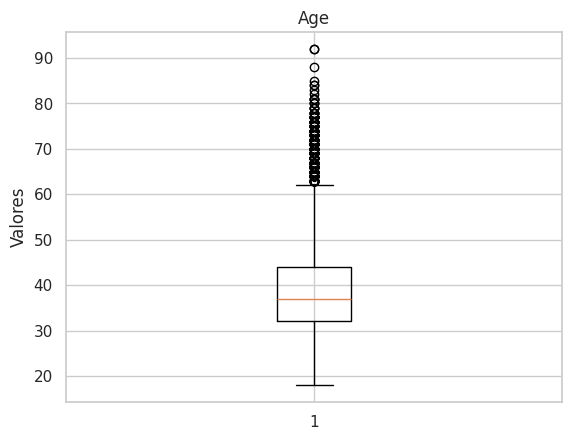

In [141]:
plt.boxplot(df_churn['Age'])
plt.title('Age')
plt.ylabel('Valores')
plt.show()

In [142]:
print(df_churn['Age'].min())
print(df_churn['Age'].max())

18
92


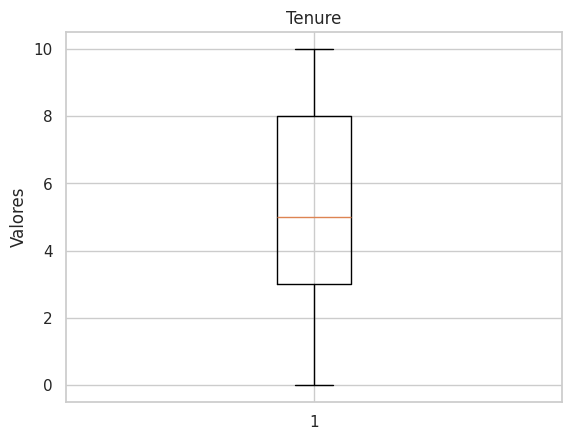

In [143]:
plt.boxplot(df_churn['Tenure'])
plt.title('Tenure')
plt.ylabel('Valores')
plt.show()

In [144]:
print(df_churn['Tenure'].min())
print(df_churn['Tenure'].max())

0
10


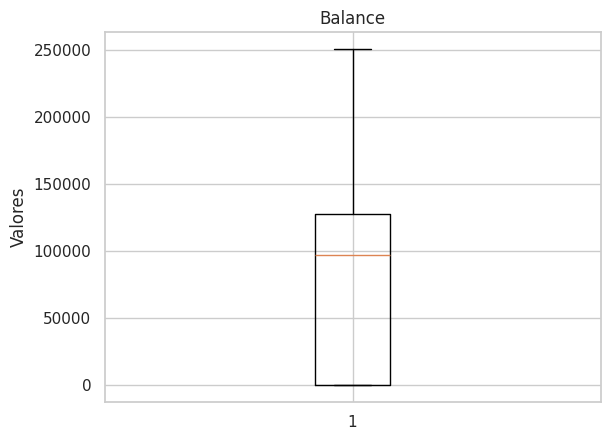

In [145]:
plt.boxplot(df_churn['Balance'])
plt.title('Balance')
plt.ylabel('Valores')
plt.show()

In [146]:
print(df_churn['Balance'].min())
print(df_churn['Balance'].max())

0.0
250898.09


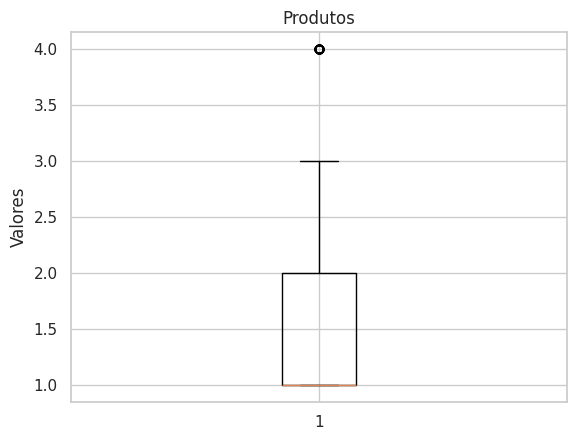

In [147]:
plt.boxplot(df_churn['NumOfProducts'])
plt.title('Produtos')
plt.ylabel('Valores')
plt.show()

In [148]:
print(df_churn['NumOfProducts'].min())
print(df_churn['NumOfProducts'].max())

1
4


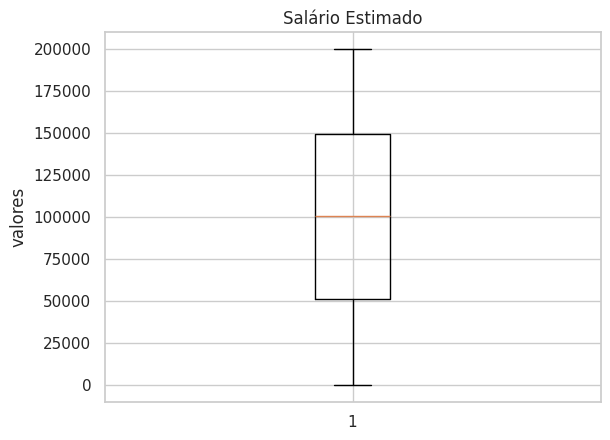

In [149]:
plt.boxplot(df_churn['EstimatedSalary'])
plt.title('Salário Estimado')
plt.ylabel('valores')
plt.show()

In [150]:
print(df_churn['EstimatedSalary'].min())
print(df_churn['EstimatedSalary'].max())

11.58
199992.48


In [151]:
from sklearn.preprocessing import LabelEncoder

In [152]:
label_encoder = LabelEncoder()

In [153]:
# Ajustar e transformar os rótulos

df_churn['Surname'] = label_encoder.fit_transform(df_churn['Surname'])
df_churn['Geography'] = label_encoder.fit_transform(df_churn['Geography'])
df_churn['Gender'] = label_encoder.fit_transform(df_churn['Gender'])

In [154]:
df_churn.head(2)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,1111,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,1173,608,2,0,41,1,83807.86,1,0,1,112542.58,0


In [155]:
from sklearn.model_selection import train_test_split

In [156]:
a = df_churn.drop(columns=['Exited'])
b = df_churn['Exited']

a_train, a_test, b_train, b_test = train_test_split(a, b, test_size=0.2, random_state=42)

In [157]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [158]:
scaler = MinMaxScaler()

In [159]:
scaler.fit(a_train)

MinMaxScaler()

In [160]:
a_train_min_max_scaled = scaler.transform(a_train)
a_test_min_max_scaled = scaler.transform(a_test)

In [161]:
a_train_min_max_scaled

array([[0.35201121, 0.11669547, 0.88507719, ..., 1.        , 0.        ,
        0.34768845],
       [0.60456274, 0.78062996, 0.35849057, ..., 1.        , 0.        ,
        0.46923837],
       [0.89393636, 0.07744496, 0.17495712, ..., 0.        , 1.        ,
        0.56001428],
       ...,
       [0.53922353, 0.03258209, 0.5626072 , ..., 0.        , 0.        ,
        0.46092526],
       [0.08595157, 0.96788994, 0.59691252, ..., 1.        , 0.        ,
        0.48738065],
       [0.7273364 , 0.56228399, 0.84425386, ..., 1.        , 1.        ,
        0.26761502]])

In [162]:
scaler = StandardScaler()

In [163]:
scaler.fit(a_train)

StandardScaler()

In [164]:
a_train_standard_scaler = scaler.transform(a_train)
a_test_standard_scaler = scaler.transform(a_test)

In [165]:
a_train_standard_scaler

array([[-0.50073964, -1.33102082,  1.28295781, ...,  0.64920701,
        -1.04034701, -0.53624445],
       [ 0.38340744,  0.98483691, -0.54107698, ...,  0.64920701,
        -1.04034701, -0.11539063],
       [ 1.39646344, -1.46792981, -1.17681548, ..., -1.54034073,
         0.96121774,  0.19891141],
       ...,
       [ 0.15466416, -1.62441517,  0.16595931, ..., -1.54034073,
        -1.04034701, -0.1441739 ],
       [-1.43217667,  1.63801503,  0.28478893, ...,  0.64920701,
        -1.04034701, -0.05257492],
       [ 0.81322062,  0.22322832,  1.14155055, ...,  0.64920701,
         0.96121774, -0.81349026]])

In [166]:
model = KNeighborsClassifier(n_neighbors=3)

model.fit(a_train, b_train)
b_pred = model.predict(a_test)

In [167]:
from sklearn.metrics import accuracy_score

In [168]:
accuracy = accuracy_score(b_test, b_pred)
print(f'Acurácia: {accuracy:.2f}')

Acurácia: 0.76


In [169]:
model_min_max = KNeighborsClassifier(n_neighbors=3)

model_min_max.fit(a_train_min_max_scaled, b_train)

b_pred_min_max = model.predict(a_test_min_max_scaled)

accuracy_min_max = accuracy_score(b_test, b_pred_min_max)
print(f'Acurácia: {accuracy_min_max:.2f}')

Acurácia: 0.81


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [170]:
model_standard = KNeighborsClassifier(n_neighbors=3)

model_standard.fit(a_train_standard_scaler, b_train)

b_pred_standard = model.predict(a_test_standard_scaler)

accuracy_standard = accuracy_score(b_test, b_pred_standard)
print(f'Acurácia: {accuracy_standard:.2f}')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Acurácia: 0.81


In [171]:
imoveis = pd.read_csv('Valorizacao_Ambiental.csv', sep=';')

In [172]:
imoveis.shape

(172, 10)

In [173]:
imoveis.isnull().sum()

,0
Ordem,0
Valor,0
Area,0
IA,0
Andar,0
Suites,0
Vista,0
DistBM,0
Semruido,0
AV100m,0


In [174]:
imoveis.describe().round(2)

,Ordem,Valor,Area,IA,Andar,Suites,Vista,DistBM,Semruido,AV100m
count,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00
mean,86.50,173541.95,163.20,5.65,4.30,1.40,0.14,505.89,0.58,0.35
std,49.80,99827.09,65.92,5.57,2.24,1.13,0.35,395.05,0.49,0.48
min,1.00,40000.00,69.00,1.00,1.00,0.00,0.00,73.00,0.00,0.00
25%,43.75,104750.00,117.00,1.00,2.75,1.00,0.00,214.75,0.00,0.00
50%,86.50,149000.00,145.00,2.50,4.00,1.00,0.00,402.50,1.00,0.00
75%,129.25,209250.00,182.00,11.00,6.00,2.00,0.00,638.00,1.00,1.00
max,172.00,579840.00,393.00,19.00,12.00,6.00,1.00,1859.00,1.00,1.00


In [175]:
# identificandi a variável target

Text(0.5, 1.0, 'Histograma da Variável valor')

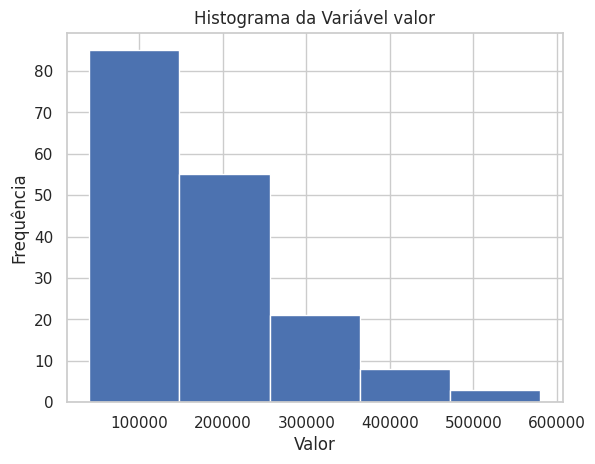

In [176]:
plt.hist(imoveis['Valor'], bins=5)
plt.ylabel('Frequência')
plt.xlabel('Valor')
plt.title('Histograma da Variável valor')

In [177]:
imoveis['raiz_valor'] = np.sqrt(imoveis['Valor'])

In [178]:
imoveis.head()

,Ordem,Valor,Area,IA,Andar,Suites,Vista,DistBM,Semruido,AV100m,raiz_valor
0,1,160000,168,1,5,1,1,294,1,0,400.000000
1,2,67000,129,1,6,0,0,1505,1,0,258.843582
2,3,190000,218,1,8,1,0,251,0,1,435.889894
3,4,110000,180,12,4,1,0,245,0,0,331.662479
4,5,70000,120,15,3,1,0,956,1,0,264.575131


Text(0.5, 1.0, 'Histograma da Variável valor após raiz quadrada')

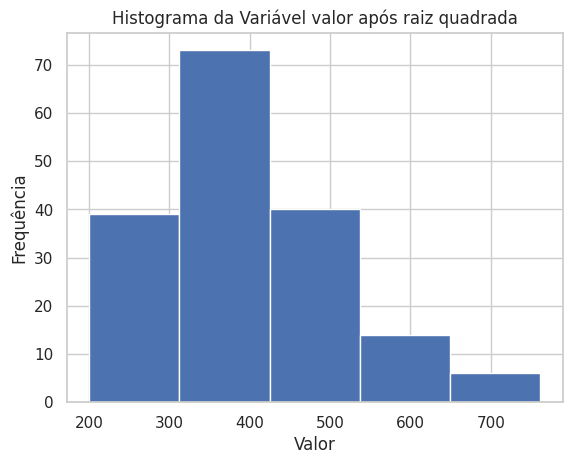

In [179]:
plt.hist(imoveis['raiz_valor'], bins=5)
plt.ylabel('Frequência')
plt.xlabel('Valor')
plt.title('Histograma da Variável valor após raiz quadrada')

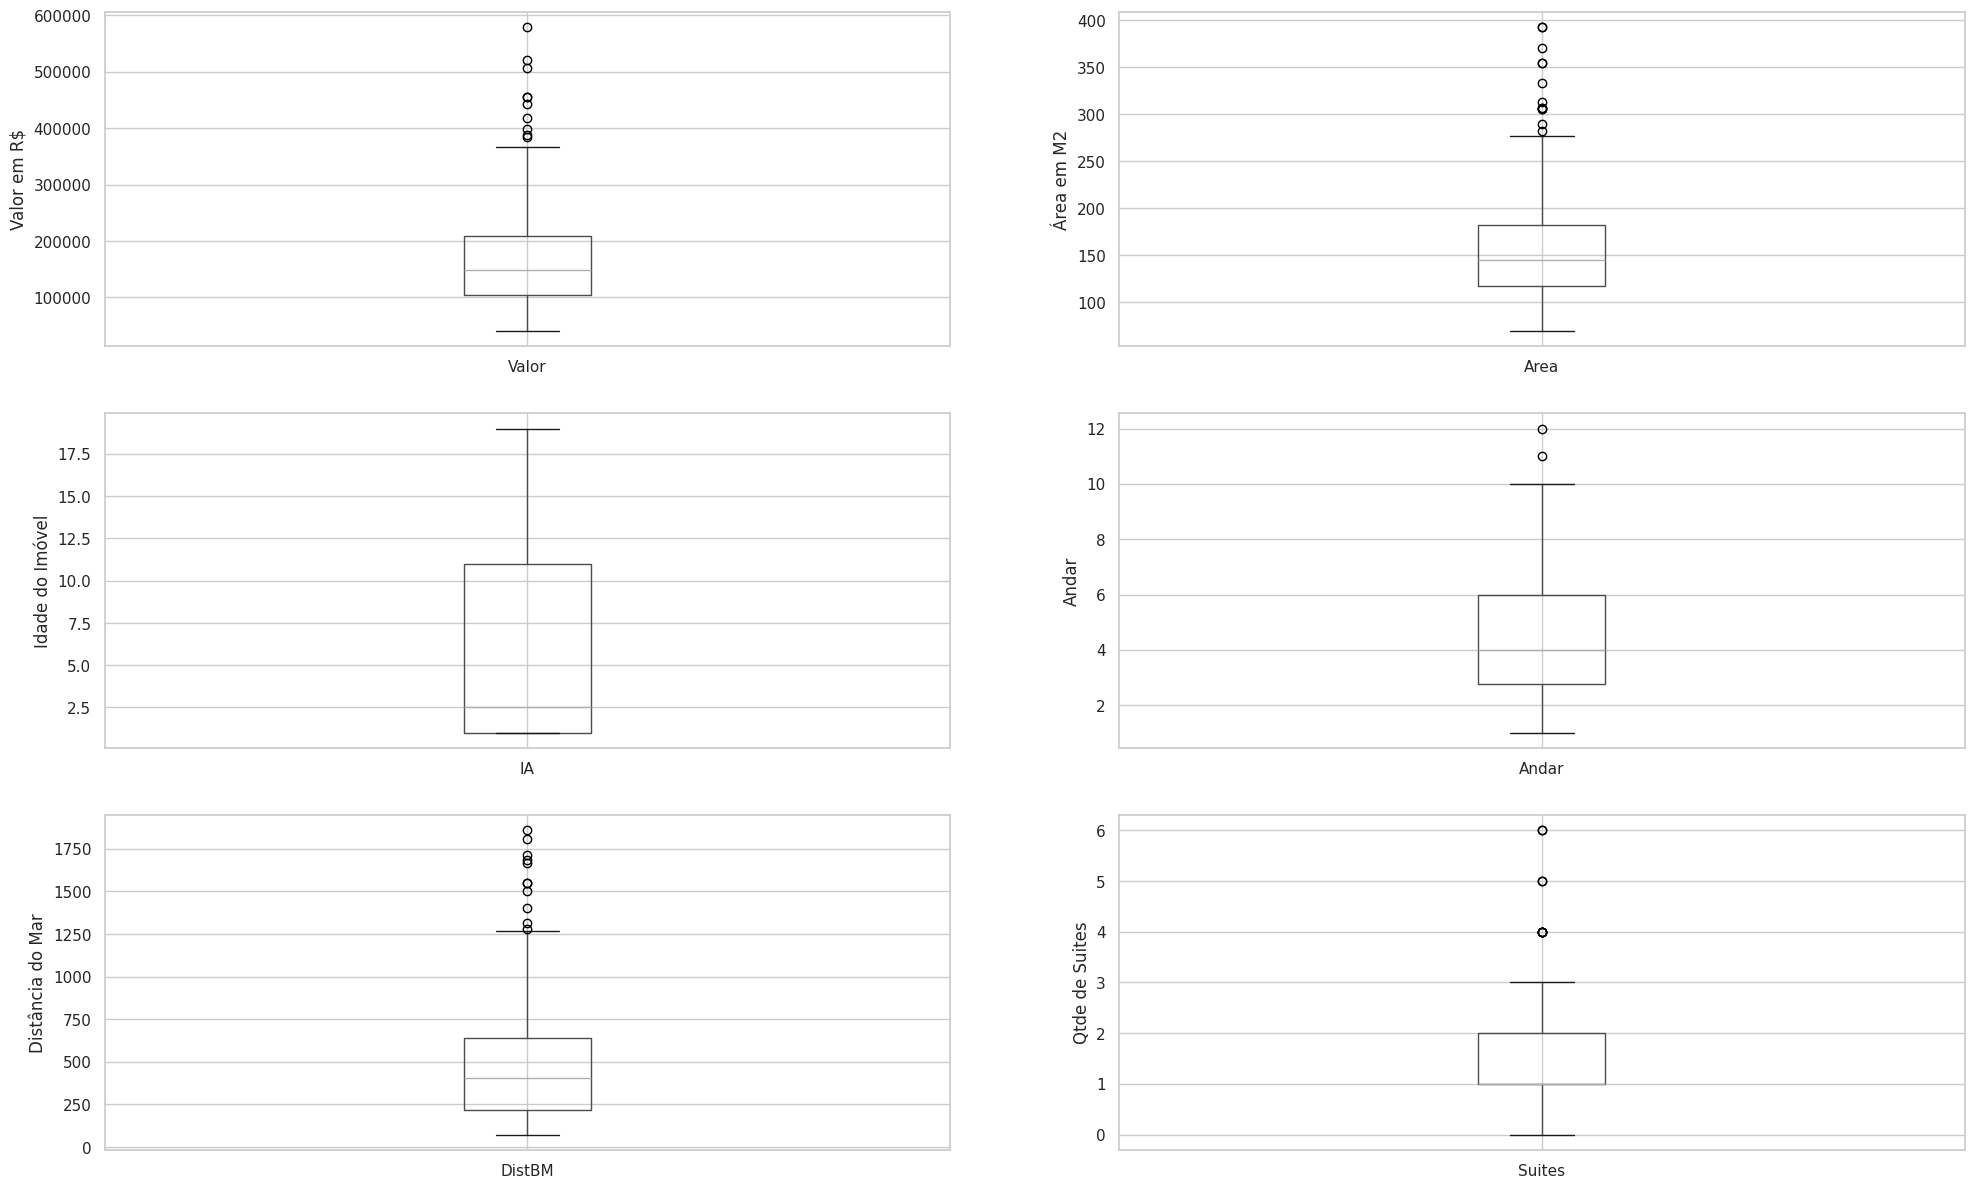

In [180]:
plt.figure(figsize=(24,20))

plt.subplot(4, 2, 1)
fig = imoveis.boxplot(column='Valor')
fig.set_ylabel('Valor em R$')

plt.subplot(4, 2, 2)
fig = imoveis.boxplot(column='Area')
fig.set_ylabel('Área em M2')

plt.subplot(4, 2, 3)
fig = imoveis.boxplot(column='IA')
fig.set_ylabel('Idade do Imóvel')

plt.subplot(4, 2, 4)
fig = imoveis.boxplot(column='Andar')
fig.set_ylabel('Andar')

plt.subplot(4, 2, 5)
fig = imoveis.boxplot(column='DistBM')
fig.set_ylabel('Distância do Mar')

plt.subplot(4, 2, 6)
fig = imoveis.boxplot(column='Suites')
fig.set_ylabel('Qtde de Suites')

plt.show()

<Axes: >

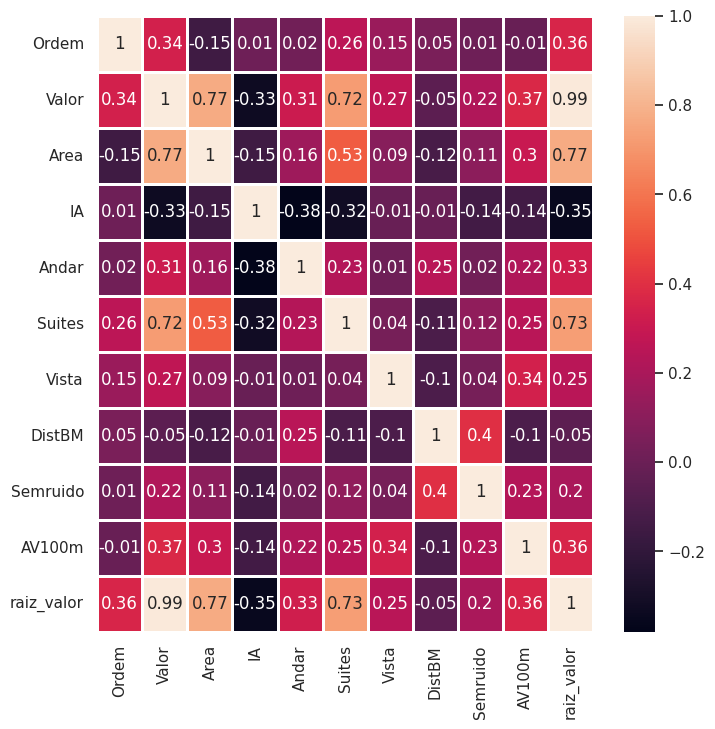

In [181]:
# criando correlação no Pandas (Pearson)
correlation_matrix = imoveis.corr().round(2)

fig, ax = plt.subplots(figsize=(8,8))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=1, ax=ax)

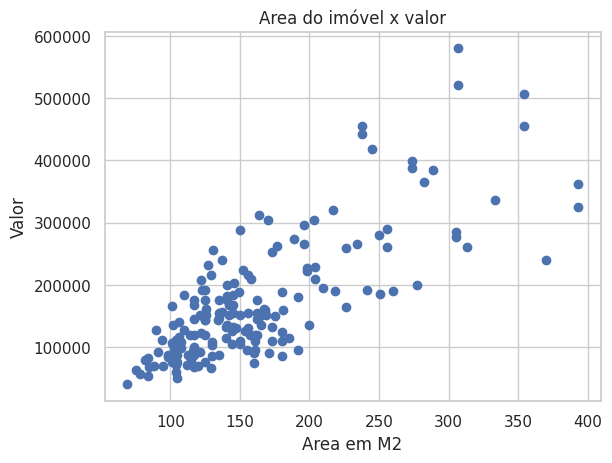

In [182]:
plt.scatter('Area', 'Valor', data=imoveis)
plt.xlabel('Area em M2')
plt.ylabel('Valor')
plt.title('Area do imóvel x valor')
plt.show()

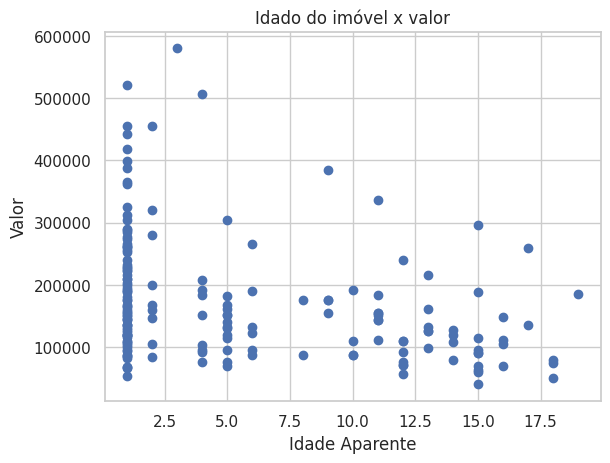

In [183]:
plt.scatter('IA', 'Valor', data=imoveis)
plt.xlabel('Idade Aparente')
plt.ylabel('Valor')
plt.title('Idado do imóvel x valor')
plt.show()

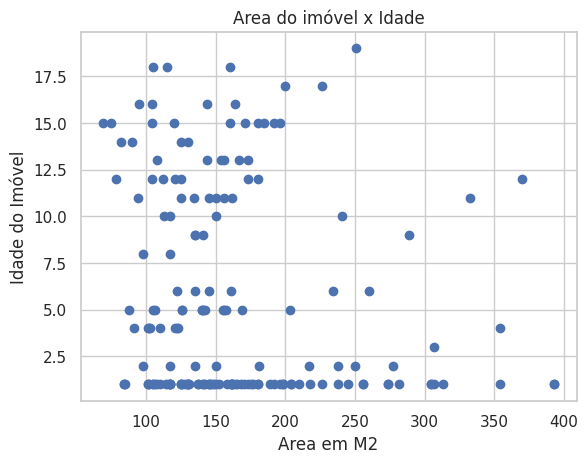

In [184]:
plt.scatter('Area', 'IA', data=imoveis)
plt.xlabel('Area em M2')
plt.ylabel('Idade do Imóvel')
plt.title('Area do imóvel x Idade')
plt.show()

/tmp/ipykernel_14570/1248837714.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Vista', y='Valor', data=imoveis, palette='hls')


<Axes: xlabel='Vista', ylabel='Valor'>

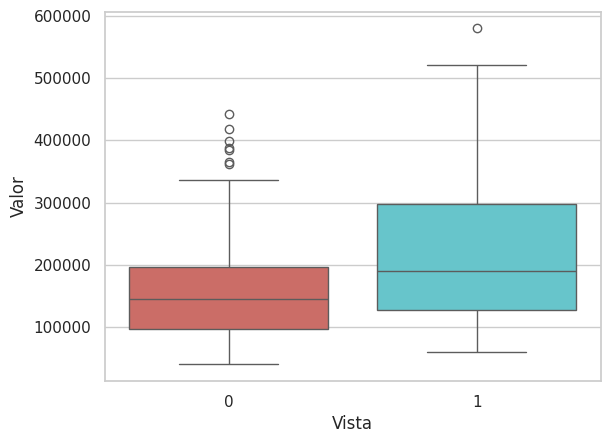

In [185]:
sns.boxplot(x='Vista', y='Valor', data=imoveis, palette='hls')

/tmp/ipykernel_14570/2241610374.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Semruido', y='Valor', data=imoveis, palette='hls')


<Axes: xlabel='Semruido', ylabel='Valor'>

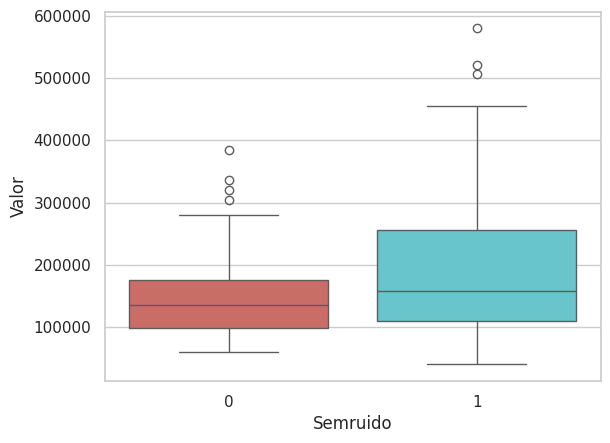

In [186]:
sns.boxplot(x='Semruido', y='Valor', data=imoveis, palette='hls')

/tmp/ipykernel_14570/3988572593.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AV100m', y='Valor', data=imoveis, palette='hls')


<Axes: xlabel='AV100m', ylabel='Valor'>

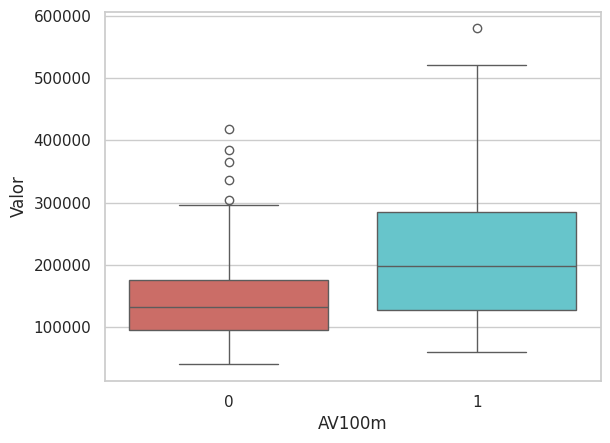

In [187]:
sns.boxplot(x='AV100m', y='Valor', data=imoveis, palette='hls')

In [188]:
from sklearn.linear_model import LinearRegression

In [189]:
lr = LinearRegression()

In [190]:
# A contém as variáveis preditoras ouy independentes
A = imoveis[['Area', 'Suites', 'IA', 'Semruido', 'Vista', 'Andar', 'AV100m', 'DistBM']]

In [191]:
# B variável target ou dependente
B = imoveis[['Valor']]

In [192]:
from sklearn.model_selection import train_test_split

In [193]:
# Separando os dados de treino e teste
A_train, A_test, B_train, B_test = train_test_split(A, B, test_size=0.2, random_state = 101)

In [194]:
# Treinando o modelo

lr.fit(A_train, B_train)

LinearRegression()

In [195]:
# Calculando o valor predito da variável resposta na amostra teste
B_pred = lr.predict(A_test)

In [196]:
# 1 - Olhar o Intercepto e os Coeficientes da Regressão
# 2 - Representa o valor esperado da variável dependente quando todas as variáveis independentes são iguais
# 3 - Em termos gráficos, o intercepto é o ponto onde a linha de regressão cruza o eixo vertica (eixo b)

print('Intercepto:', lr.intercept_)

Intercepto: [-40165.8752773]


In [197]:
# Os coeficientes da regressão linear representam as inclinações da linha de regressão para cada variáveis

coefficients = pd.concat([pd.DataFrame(A.columns), pd.DataFrame(np.transpose(lr.coef_))], axis = 1)


In [198]:
coefficients

,0,0
0,Area,815.218075
1,Suites,34315.785459
2,IA,-1052.417100
3,Semruido,17027.508944
4,Vista,63486.030935
5,Andar,5635.237485
6,AV100m,-5672.535051
7,DistBM,-2.522530


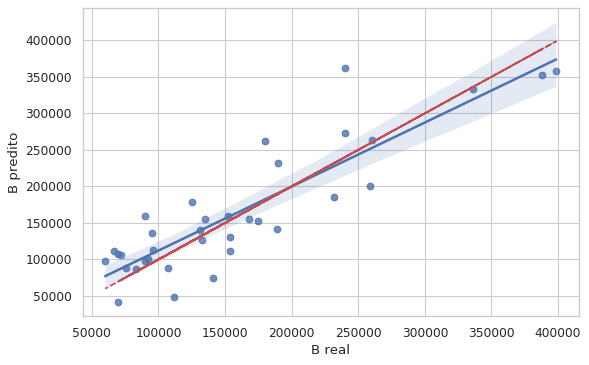

In [199]:
fig = plt.figure(figsize=(8, 5), dpi=80)
plt.rcParams.update({'font.size': 14})
ax = sns.regplot(x = B_test, y = B_pred)
ax.set(xlabel='B real', ylabel='B predito')
ax = plt.plot(B_test, B_test, '--r')
plt.show()

In [200]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [201]:
# Avaliando o modelo

MAE = mean_absolute_error(B_test, B_pred)
MSE = mean_squared_error(B_test, B_pred)
r2 = r2_score(B_test, B_pred)

print('MAE', MAE) # Mean Absolute Error é a média do valor absoluto dos erros
print('MSE', MSE) # Erro Quadrático Médio é a média dos erros quadráticos
print('r²', r2) # R quadrado

MAE 34422.98857094584
MSE 1844288772.1790097
r² 0.7584591969125003


In [202]:
from sklearn.tree import DecisionTreeRegressor

In [203]:
# Criando o modelo de DecisionTreeRegressor

model_dtr = DecisionTreeRegressor(random_state=101, max_depth=10)
model_dtr.fit(A_train, B_train)

DecisionTreeRegressor(max_depth=10, random_state=101)

In [204]:
B_pred_model_dtr = model_dtr.predict(A_test)

In [205]:
# Avaliando o modelo

MAE = mean_absolute_error(B_test, B_pred_model_dtr)
MSE = mean_squared_error(B_test, B_pred_model_dtr)
r2 = r2_score(B_test, B_pred_model_dtr)

print('MAE', MAE) # Mean Absolute Error é a média do valor absoluto dos erros
print('MSE', MSE) # Erro Quadrático Médio é a média dos erros quadráticos
print('r²', r2) # R quadrado

MAE 44913.75102040816
MSE 3223969337.3848395
r² 0.577766695417574


In [206]:
from sklearn.svm import SVR

In [207]:
# Criando o modelo de SVR
svr = SVR(kernel='linear')

In [208]:
svr.fit(A_train, B_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR(kernel='linear')

In [209]:
B_pred_svr = svr.predict(A_test)

In [210]:
# Avaliando o modelo

MAE = mean_absolute_error(B_test, B_pred_svr)
MSE = mean_squared_error(B_test, B_pred_svr)
r2 = r2_score(B_test, B_pred_svr)

print('MAE', MAE) # Mean Absolute Error é a média do valor absoluto dos erros
print('MSE', MSE) # Erro Quadrático Médio é a média dos erros quadráticos
print('r²', r2) # R quadrado

MAE 43153.53918496288
MSE 3123421996.7782364
r² 0.5909350700044546
